# Prediksi Kandungan Organik Tanah

Notebook ini menyelesaikan dua tujuan:

1. membangun model regresi untuk memprediksi `property_organic_content` pada data test;
2. menjawab 10 research question dengan analisis statistik, visualisasi, dan bukti empiris.

**Catatan konteks:** meskipun narasi tugas menyebut kontribusi untuk Indonesia, label bioma seperti
*Cerrado*, *Mata Atlantica*, *Amazonia*, dan *Caatinga* menunjukkan bahwa observasi pada dataset ini
merepresentasikan ekosistem Brasil. Karena itu, kesimpulan ekologis di notebook ini dibatasi pada
dataset; penerapan ke Indonesia memerlukan validasi domain dan kalibrasi lokal.

## 1. Setup dan konfigurasi

Notebook menggunakan CatBoost karena dapat menangani fitur numerik yang hilang dan fitur kategorikal
secara native. Jalankan notebook dengan interpreter `.venv/Scripts/python.exe`.

In [1]:
import os
import warnings
from pathlib import Path

# Cache Matplotlib diarahkan ke folder project agar notebook portabel pada environment terbatas.
os.environ["MPLCONFIGDIR"] = str((Path.cwd() / ".mplconfig").resolve())
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_log_error,
    median_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from catboost import CatBoostRegressor

RANDOM_STATE = 42
TARGET = "property_organic_content"
N_FOLDS = 5
CATBOOST_ITERATIONS = 1000

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#1B4332", "#2D6A4F", "#40916C", "#74C69D", "#B7E4C7"]
plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("Setup selesai.")

Setup selesai.


## 2. Membaca data dan memeriksa struktur

In [2]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

assert TARGET in train.columns and TARGET not in test.columns
assert list(sample_submission.columns) == ["sample_id", TARGET]
assert sample_submission["sample_id"].equals(test["sample_id"])
assert len(sample_submission) == len(test)

structure = pd.DataFrame({
    "dataset": ["train", "test", "sample_submission"],
    "baris": [len(train), len(test), len(sample_submission)],
    "kolom": [train.shape[1], test.shape[1], sample_submission.shape[1]],
    "duplikat_baris": [
        train.duplicated().sum(),
        test.duplicated().sum(),
        sample_submission.duplicated().sum(),
    ],
})
display(structure)
display(train.head(3))

,dataset,baris,kolom,duplikat_baris
0,train,11210,52,0
1,test,2670,51,0
2,sample_submission,2670,2,0


,sample_id,source_id,has_band_A_spectrum,has_band_B_spectrum,sampling_strategy,sampling_depth_cm,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,biome,parent_rock_type,property_particle_coarse,property_particle_fine,property_organic_content,property_acidity_index,cation_Ca,cation_Mg,cation_Na,cation_exchange_capacity,latitude,longitude,spectral_band_A_PC_1,spectral_band_A_PC_2,spectral_band_A_PC_3,spectral_band_A_PC_4,spectral_band_A_PC_5,spectral_band_A_PC_6,spectral_band_A_PC_7,spectral_band_A_PC_8,spectral_band_A_PC_9,spectral_band_A_PC_10,spectral_band_A_PC_11,spectral_band_A_PC_12,spectral_band_A_PC_13,spectral_band_A_PC_14,spectral_band_A_PC_15,spectral_band_B_PC_1,spectral_band_B_PC_2,spectral_band_B_PC_3,spectral_band_B_PC_4,spectral_band_B_PC_5,spectral_band_B_PC_6,spectral_band_B_PC_7,spectral_band_B_PC_8,spectral_band_B_PC_9,spectral_band_B_PC_10,spectral_band_B_PC_11,spectral_band_B_PC_12,spectral_band_B_PC_13,spectral_band_B_PC_14,spectral_band_B_PC_15
0,train_00001,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,Mata Atlantica,Sedimentary Rock,"2,494.4225",386.4156,20.3872,NaN,22.6194,24.5044,NaN,101.4734,NaN,NaN,0.4436,0.3445,0.3572,-0.1831,0.0989,-0.0232,0.0475,-0.0021,-0.0288,0.0018,0.0078,0.0070,0.0134,0.0102,-0.0017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,train_00002,Source_10,YES,NO,Auger,0-20,MW,Loc_011,State_10,Savannah,Cerrado,Igneous Rock,NaN,NaN,30.7426,15.0796,NaN,NaN,NaN,NaN,-28.3928,-49.3969,-2.0265,0.5128,-0.5988,0.1433,0.1156,0.1513,-0.1911,-0.1721,0.0429,-0.0497,-0.0139,-0.0412,0.0232,0.0120,-0.0429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,train_00003,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,Unknown,Unknown,NaN,NaN,25.9370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.9740,1.2607,0.3868,0.3299,-0.0628,-0.0527,-0.0704,-0.0143,-0.0748,-0.0211,0.0732,-0.0947,-0.0287,-0.0240,-0.0034,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
schema = pd.DataFrame({
    "dtype_train": train.dtypes.astype(str),
    "missing_train_pct": train.isna().mean().mul(100),
    "missing_test_pct": test.isna().mean().mul(100),
    "n_unique_train": train.nunique(dropna=False),
}).sort_values("missing_train_pct", ascending=False)

categorical_cols_original = train.drop(columns=TARGET).select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()
numeric_cols_original = train.select_dtypes(include=np.number).columns.tolist()

print(f"Fitur kategorikal: {len(categorical_cols_original)}")
print(f"Fitur numerik (termasuk target): {len(numeric_cols_original)}")
display(schema.head(25))

Fitur kategorikal: 12
Fitur numerik (termasuk target): 40


,dtype_train,missing_train_pct,missing_test_pct,n_unique_train
cation_Na,float64,96.4139,96.4419,212
spectral_band_B_PC_7,float64,84.8885,88.8390,1695
spectral_band_B_PC_9,float64,84.8885,88.8390,1695
spectral_band_B_PC_2,float64,84.8885,88.8390,1695
spectral_band_B_PC_6,float64,84.8885,88.8390,1695
spectral_band_B_PC_1,float64,84.8885,88.8390,1695
spectral_band_B_PC_11,float64,84.8885,88.8390,1695
spectral_band_B_PC_10,float64,84.8885,88.8390,1695
spectral_band_B_PC_14,float64,84.8885,88.8390,1695
spectral_band_B_PC_13,float64,84.8885,88.8390,1695


## 3. Eksplorasi data awal

,nilai
count,"11,210.0000"
mean,34.1425
std,23.1986
min,2.1574
1%,5.5121
5%,11.3262
10%,12.9442
25%,18.1219
50%,27.5065
75%,43.6868


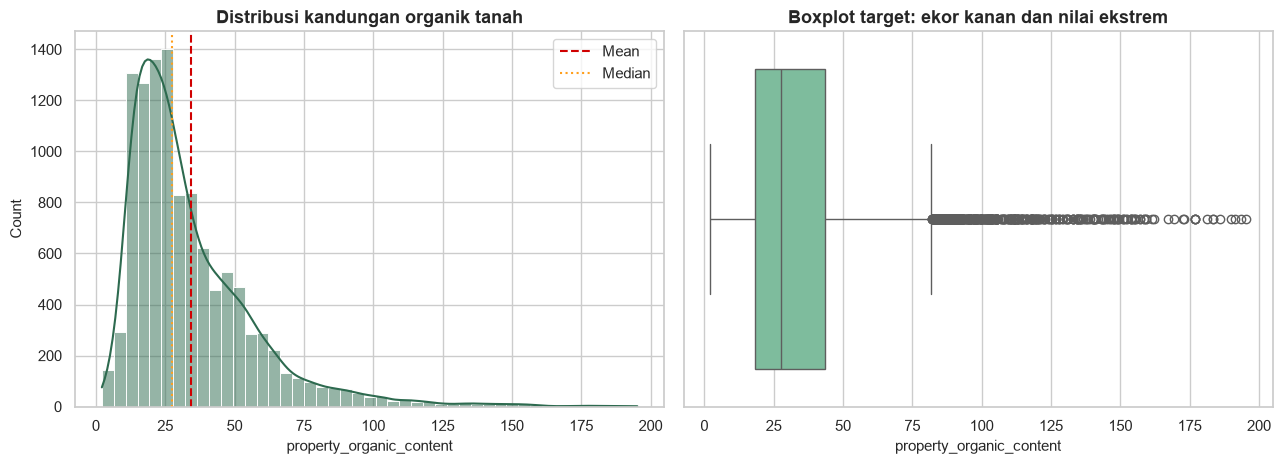

In [4]:
target_summary = train[TARGET].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame("nilai")
target_summary.loc["skewness"] = train[TARGET].skew()
target_summary.loc["kurtosis"] = train[TARGET].kurt()
display(target_summary)

_, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(train[TARGET], bins=45, kde=True, color=PALETTE[1], ax=axes[0])
axes[0].axvline(train[TARGET].mean(), color="#D00000", ls="--", label="Mean")
axes[0].axvline(train[TARGET].median(), color="#FF9F1C", ls=":", label="Median")
axes[0].set_title("Distribusi kandungan organik tanah")
axes[0].legend()

sns.boxplot(x=train[TARGET], color=PALETTE[3], ax=axes[1])
axes[1].set_title("Boxplot target: ekor kanan dan nilai ekstrem")
axes[1].set_xlabel("property_organic_content")
plt.tight_layout()
plt.show()

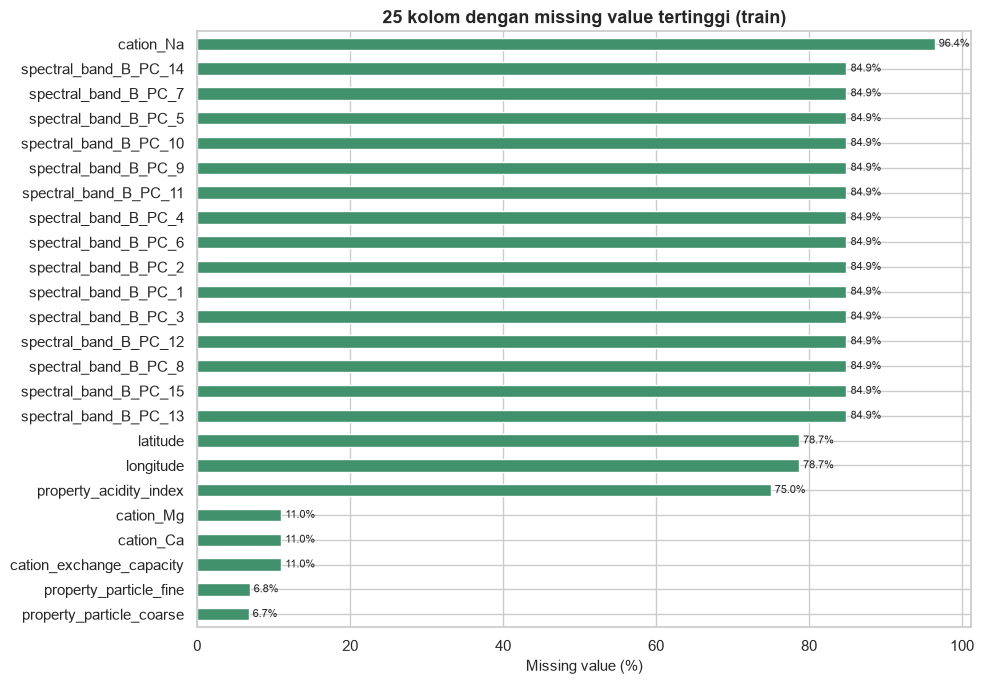

col_0,Available,Missing,All
has_band_B_spectrum,,,
NO,470,9516,9986
YES,1224,0,1224
All,1694,9516,11210


In [5]:
missing = train.isna().mean().mul(100).sort_values(ascending=False)
missing_top = missing[missing > 0].head(25).sort_values()

plt.figure(figsize=(10, 7))
ax = missing_top.plot(kind="barh", color=PALETTE[2])
ax.set_title("25 kolom dengan missing value tertinggi (train)")
ax.set_xlabel("Missing value (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

band_b_cols = [c for c in train.columns if c.startswith("spectral_band_B_PC_")]
band_b_actual = np.where(train[band_b_cols].notna().any(axis=1), "Available", "Missing")
band_b_check = pd.crosstab(
    train["has_band_B_spectrum"],
    band_b_actual,
    margins=True,
)
display(band_b_check)

**Temuan EDA utama**

- Train berisi **11.210** sampel dan test **2.670** sampel.
- Target memiliki mean sekitar **34,14**, median **27,51**, dan skewness sekitar **2,03**.
  Artinya distribusi tidak simetris dan memiliki ekor kanan panjang.
- Semua komponen band A tersedia, sedangkan sekitar **84,9%** komponen band B hilang.
- Flag `has_band_B_spectrum` tidak sepenuhnya konsisten dengan nilai aktual: sebagian baris berlabel
  `NO` tetap memiliki komponen band B. Feature engineering akan menggunakan indikator ketersediaan
  band B yang dihitung langsung dari kolom spektral.
- `cation_Na`, koordinat, dan indeks keasaman juga memiliki missingness tinggi. Menghapus seluruh baris
  tidak layak karena akan membuang mayoritas data.

## Soal 1. Urgensi bisnis dan kebijakan pangan

Prediksi kandungan organik tanah **mendesak sebagai alat screening dan prioritisasi**, tetapi bukan
pengganti total uji laboratorium.

- **Efisiensi biaya:** peta prediksi memungkinkan laboratorium berfokus pada lokasi berisiko atau
  berketidakpastian tinggi. Pengambilan sampel, transportasi, reagen, dan waktu analis dapat dialokasikan
  secara lebih selektif daripada melakukan pengujian merata di semua lahan.
- **Keputusan input yang lebih tepat:** kandungan organik berhubungan dengan retensi air, struktur tanah,
  aktivitas biologis, dan kapasitas menahan unsur hara. Prediksi spasial mendukung pemupukan, pemberian
  bahan organik, dan pengapuran secara spesifik lokasi sehingga mengurangi pemborosan input.
- **Manajemen berkelanjutan:** pemantauan berkala membantu mengidentifikasi degradasi, erosi, atau
  kehilangan karbon tanah lebih awal. Kebijakan konservasi dapat diprioritaskan pada wilayah dengan
  nilai rendah atau tren menurun.
- **Batas penggunaan:** keputusan berisiko tinggi tetap perlu dikonfirmasi dengan sampel laboratorium.
  Model sebaiknya dipakai sebagai sistem pendukung keputusan dengan audit error per wilayah dan
  mekanisme pembaruan data.

## Soal 3. Perbedaan distribusi antarwilayah dan interpretasi ekosistem

,count,mean,median,std
geo_zone_macro,,,,
S,1022,57.2668,55.7897,36.4520
NE,512,42.3672,35.1922,31.2203
MW,2930,34.5005,29.1245,20.5871
N,979,34.3947,30.7426,19.6251
SE,5767,29.0897,24.2705,17.8190


Kruskal-Wallis zona makro: H=747.42, p-value=1.879e-160


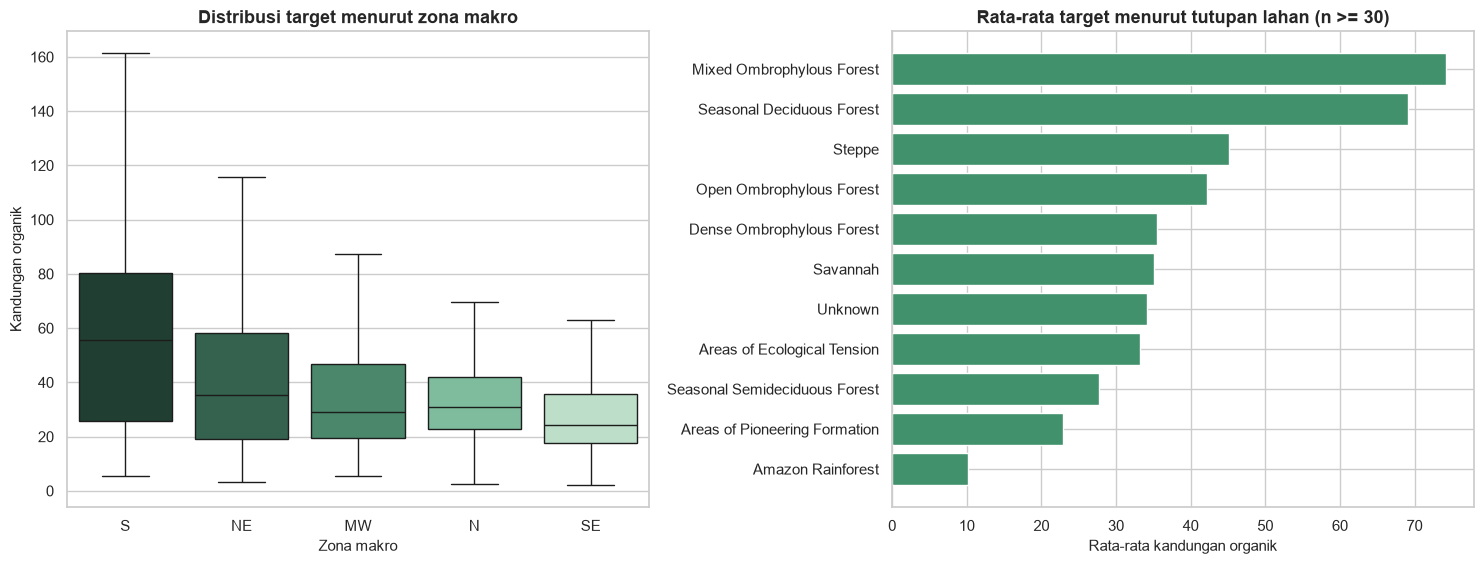

In [6]:
macro_summary = (
    train.groupby("geo_zone_macro")[TARGET]
    .agg(count="size", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
)
landcover_summary = (
    train.groupby("land_cover_type")[TARGET]
    .agg(count="size", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
)

macro_groups = [g[TARGET].values for _, g in train.groupby("geo_zone_macro")]
kw_macro = stats.kruskal(*macro_groups)

display(macro_summary)
print(f"Kruskal-Wallis zona makro: H={kw_macro.statistic:,.2f}, p-value={kw_macro.pvalue:.3e}")

_, axes = plt.subplots(1, 2, figsize=(15, 5.8))
order_macro = macro_summary.index
sns.boxplot(
    data=train, x="geo_zone_macro", y=TARGET, order=order_macro,
    showfliers=False, palette=PALETTE, ax=axes[0]
)
axes[0].set_title("Distribusi target menurut zona makro")
axes[0].set_xlabel("Zona makro")
axes[0].set_ylabel("Kandungan organik")

lc_plot = landcover_summary.query("count >= 30").sort_values("mean")
axes[1].barh(lc_plot.index, lc_plot["mean"], color=PALETTE[2])
axes[1].set_title("Rata-rata target menurut tutupan lahan (n >= 30)")
axes[1].set_xlabel("Rata-rata kandungan organik")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

**Jawaban Soal 3**

Ya, distribusi berbeda secara signifikan. Uji Kruskal-Wallis pada zona makro menghasilkan
**H sekitar 747,42** dengan **p < 0,001**, sehingga hipotesis bahwa semua zona memiliki distribusi yang
sama ditolak. Zona **S** memiliki mean tertinggi (sekitar **57,27**), sedangkan **SE** terendah
(sekitar **29,09**).

Secara jumlah observasi, dataset paling banyak merepresentasikan zona **SE**, bioma
**Mata Atlantica**, serta tutupan **Seasonal Semideciduous Forest**; kelompok besar lain adalah
**Cerrado/Savannah**. Ini menunjukkan dominasi ekosistem hutan tropis-subtropis musiman dan savana.
Tutupan *Mixed Ombrophylous Forest* dan *Seasonal Deciduous Forest* memiliki rata-rata target tinggi,
konsisten dengan akumulasi serasah dan kondisi yang memungkinkan penyimpanan bahan organik. Namun,
interpretasi ekologis tidak boleh hanya berdasarkan mean karena komposisi sumber data, batuan induk,
tekstur tanah, dan ukuran sampel berbeda antar kelompok.

## Soal 4. Hubungan antar tingkat wilayah dan rasio rata-rata

,n_group_total,n_group_n_ge_20,min_group,min_mean,max_group,max_mean,max_min_ratio,eta_squared
level,,,,,,,,
geo_zone_macro,5,5,SE,29.0897,S,57.2668,1.9686,0.1208
geo_zone_meso,23,18,State_18,18.8800,State_03,72.9516,3.8640,0.2747
geo_zone_micro,50,23,Loc_023,10.2256,Loc_005,86.7856,8.4871,0.2734


,geo_zone_macro,geo_zone_meso,geo_zone_micro
geo_zone_macro,1.0000,0.6201,0.3257
geo_zone_meso,0.6201,1.0000,0.5361
geo_zone_micro,0.3257,0.5361,1.0000


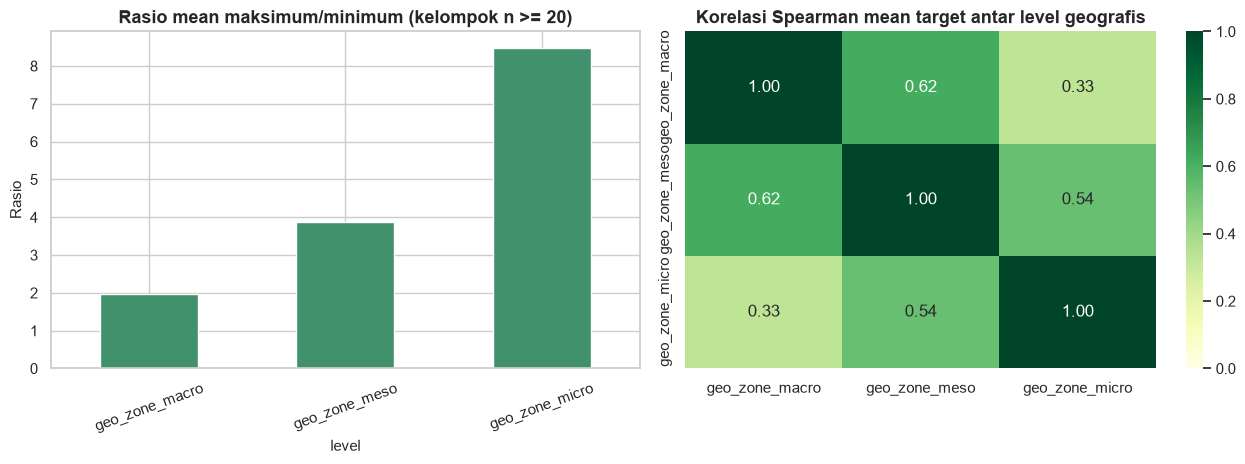

In [7]:
def eta_squared(data, group_col, target_col):
    grand_mean = data[target_col].mean()
    ss_between = sum(
        len(group) * (group[target_col].mean() - grand_mean) ** 2
        for _, group in data.groupby(group_col)
    )
    ss_total = ((data[target_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total

geo_levels = ["geo_zone_macro", "geo_zone_meso", "geo_zone_micro"]
geo_rows = []
geo_mean_encoded = pd.DataFrame(index=train.index)

for level in geo_levels:
    grouped = train.groupby(level)[TARGET].agg(["count", "mean"]).sort_values("mean")
    stable = grouped[grouped["count"] >= 20]
    geo_rows.append({
        "level": level,
        "n_group_total": len(grouped),
        "n_group_n_ge_20": len(stable),
        "min_group": stable.index[0],
        "min_mean": stable.iloc[0]["mean"],
        "max_group": stable.index[-1],
        "max_mean": stable.iloc[-1]["mean"],
        "max_min_ratio": stable.iloc[-1]["mean"] / stable.iloc[0]["mean"],
        "eta_squared": eta_squared(train, level, TARGET),
    })
    geo_mean_encoded[level] = train[level].map(train.groupby(level)[TARGET].mean())

geo_comparison = pd.DataFrame(geo_rows).set_index("level")
geo_corr = geo_mean_encoded.corr(method="spearman")
display(geo_comparison)
display(geo_corr)

_, axes = plt.subplots(1, 2, figsize=(13, 4.8))
geo_comparison["max_min_ratio"].plot(kind="bar", color=PALETTE[2], ax=axes[0])
axes[0].set_title("Rasio mean maksimum/minimum (kelompok n >= 20)")
axes[0].set_ylabel("Rasio")
axes[0].tick_params(axis="x", rotation=20)

sns.heatmap(geo_corr, annot=True, fmt=".2f", cmap="YlGn", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Korelasi Spearman mean target antar level geografis")
plt.tight_layout()
plt.show()

**Jawaban Soal 4**

Terdapat hubungan hierarkis yang bermakna, tetapi tidak sempurna. Korelasi Spearman mean kelompok
yang dipetakan kembali ke sampel adalah sekitar **0,62** untuk makro-meso, **0,54** untuk meso-mikro,
dan **0,33** untuk makro-mikro. Variasi lokal tetap besar sehingga satu kode makro tidak cukup untuk
mewakili kondisi mikro.

Dengan menyaring kelompok yang memiliki minimal 20 sampel, rasio mean maksimum terhadap minimum
meningkat dari sekitar **1,97x** pada level makro menjadi **3,86x** pada meso dan **8,49x** pada mikro.
Eta-squared deskriptif juga meningkat dari sekitar **0,12** pada makro menjadi sekitar **0,27** pada
meso/mikro.

Implikasi modeling: semua tingkat geografis dipertahankan, ditambah fitur interaksi hierarki
`macro|meso|micro`. Validasi tetap diacak secara terstratifikasi untuk selaras dengan format kompetisi,
tetapi untuk deployment nyata sebaiknya ditambah *spatial/group validation* agar performa pada wilayah
baru tidak terlalu optimistis.

## Soal 5a. Kondisi keasaman rendah dan KTK di bawah rata-rata

Persentil 25 acidity index: 12.8805
Rata-rata cation exchange capacity: 169.1421
Jumlah sampel yang memenuhi kondisi: 388


,count,mean,median,std
biome,,,,
Unknown,1,43.6868,43.6868,NaN
Amazonia,197,27.6124,27.5065,6.7311
Cerrado,2,24.2705,24.2705,0.0000
Mata Atlantica,186,21.3180,21.0344,10.0405
Caatinga,2,19.9827,19.9827,1.2585


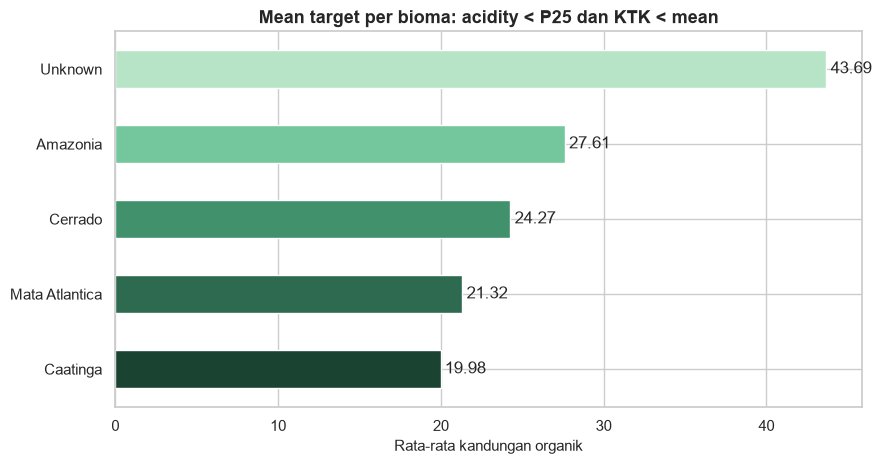

In [8]:
acidity_q25 = train["property_acidity_index"].quantile(0.25)
cec_mean = train["cation_exchange_capacity"].mean()

subset_5a = train[
    (train["property_acidity_index"] < acidity_q25)
    & (train["cation_exchange_capacity"] < cec_mean)
].copy()

q5a_summary = (
    subset_5a.groupby("biome")[TARGET]
    .agg(count="size", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
)

print(f"Persentil 25 acidity index: {acidity_q25:,.4f}")
print(f"Rata-rata cation exchange capacity: {cec_mean:,.4f}")
print(f"Jumlah sampel yang memenuhi kondisi: {len(subset_5a):,}")
display(q5a_summary)

plt.figure(figsize=(9, 4.8))
colors = [PALETTE[min(i, len(PALETTE) - 1)] for i in range(len(q5a_summary))]
ax = q5a_summary["mean"].sort_values().plot(kind="barh", color=colors)
ax.set_title("Mean target per bioma: acidity < P25 dan KTK < mean")
ax.set_xlabel("Rata-rata kandungan organik")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
plt.tight_layout()
plt.show()

**Jawaban Soal 5a**

Ambang yang digunakan adalah `property_acidity_index < 12,8805` dan
`cation_exchange_capacity < 169,1421`. Terdapat **388** sampel yang memenuhi kedua kondisi.
Mean target pada kelompok dengan ukuran memadai adalah sekitar **27,61** untuk Amazonia (n=197)
dan **21,32** untuk Mata Atlantica (n=186). Cerrado, Caatinga, dan Unknown hanya memiliki 1-2 sampel,
sehingga mean-nya tidak cukup stabil untuk generalisasi.

Insight utamanya: keasaman rendah dan KTK di bawah rata-rata tidak menghasilkan level bahan organik
yang seragam; konteks bioma tetap penting. Selain itu, ketimpangan ukuran sampel perlu selalu ditampilkan
bersama mean agar kelompok sangat kecil tidak disalahartikan sebagai pola ekologis yang kuat.

## Soal 5b. Outlier pada kombinasi tutupan lahan dan wilayah

,land_cover_type,geo_zone_macro,n,outliers,outlier_rate,mean_target,max_target,kombinasi
0,Amazon Rainforest,NE,32,4,0.1250,10.2256,25.6188,Amazon Rainforest | NE
25,Seasonal Semideciduous Forest,SE,3150,235,0.0746,26.0721,155.3309,Seasonal Semideciduous Forest | SE
27,Unknown,MW,541,38,0.0702,40.8451,177.0610,Unknown | MW
2,Areas of Ecological Tension,N,38,2,0.0526,56.7401,131.0604,Areas of Ecological Tension | N
26,Steppe,NE,77,3,0.0390,45.0983,185.9440,Steppe | NE
21,Seasonal Deciduous Forest,S,487,18,0.0370,71.0500,189.7949,Seasonal Deciduous Forest | S
18,Savannah,N,374,13,0.0348,29.9321,90.6097,Savannah | N
1,Areas of Ecological Tension,MW,1028,31,0.0302,30.3010,88.6680,Areas of Ecological Tension | MW
5,Areas of Ecological Tension,SE,145,4,0.0276,41.7878,135.1055,Areas of Ecological Tension | SE
20,Savannah,SE,1709,45,0.0263,35.3806,181.2194,Savannah | SE


,sample_id,land_cover_type,geo_zone_macro,property_organic_content,lower_bound,upper_bound
3041,train_03042,Areas of Ecological Tension,NE,195.2315,9.8498,74.9269
1453,train_01454,Dense Ombrophylous Forest,NE,193.6782,-69.0737,155.2500
10245,train_10246,Seasonal Deciduous Forest,S,189.7949,-15.1326,151.6863
6873,train_06874,Steppe,NE,185.9440,-14.5623,98.0526
669,train_00670,Seasonal Deciduous Forest,S,183.4037,-15.1326,151.6863
7562,train_07563,Seasonal Deciduous Forest,S,183.4037,-15.1326,151.6863
9218,train_09219,Savannah,SE,181.2194,-12.9442,80.2543
6469,train_06470,Unknown,MW,177.0610,-33.1696,102.7449
587,train_00588,Unknown,MW,177.0610,-33.1696,102.7449
10602,train_10603,Unknown,MW,177.0610,-33.1696,102.7449


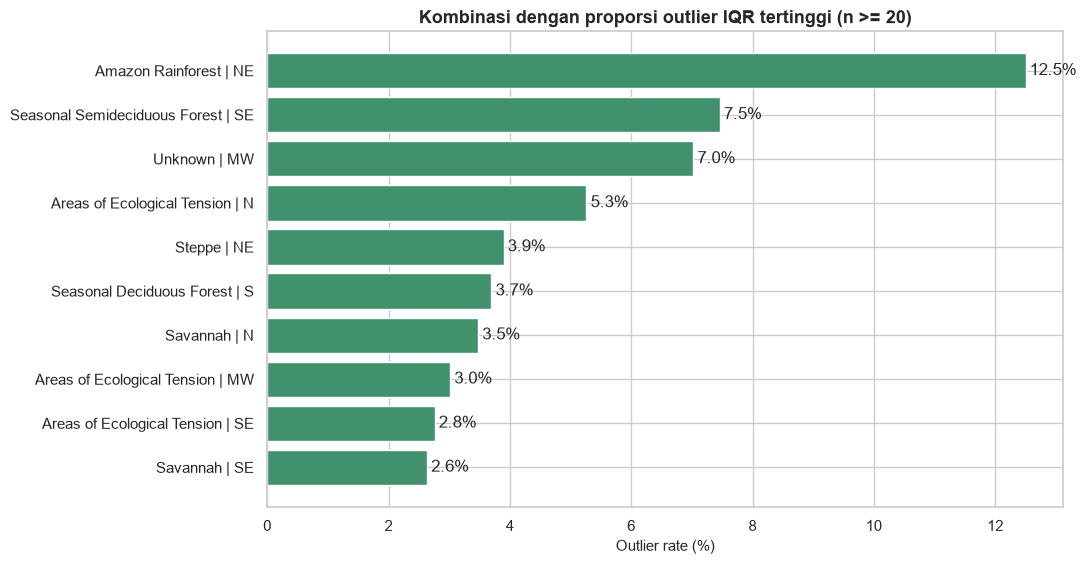

In [9]:
combo_stats = (
    train.groupby(["land_cover_type", "geo_zone_macro"])[TARGET]
    .agg(
        count="size",
        mean="mean",
        median="median",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
    )
    .reset_index()
)
combo_stats["iqr"] = combo_stats["q3"] - combo_stats["q1"]
combo_stats["lower_bound"] = combo_stats["q1"] - 1.5 * combo_stats["iqr"]
combo_stats["upper_bound"] = combo_stats["q3"] + 1.5 * combo_stats["iqr"]

outlier_data = train.merge(
    combo_stats,
    on=["land_cover_type", "geo_zone_macro"],
    how="left",
)
outlier_data["is_outlier"] = (
    (outlier_data[TARGET] < outlier_data["lower_bound"])
    | (outlier_data[TARGET] > outlier_data["upper_bound"])
)

outlier_combo = (
    outlier_data.groupby(["land_cover_type", "geo_zone_macro"])
    .agg(
        n=(TARGET, "size"),
        outliers=("is_outlier", "sum"),
        outlier_rate=("is_outlier", "mean"),
        mean_target=(TARGET, "mean"),
        max_target=(TARGET, "max"),
    )
    .reset_index()
)
outlier_combo["kombinasi"] = (
    outlier_combo["land_cover_type"] + " | " + outlier_combo["geo_zone_macro"]
)
reliable_outliers = (
    outlier_combo.query("n >= 20")
    .sort_values(["outlier_rate", "outliers"], ascending=False)
)
display(reliable_outliers.head(15))

top_individual_outliers = (
    outlier_data.loc[outlier_data["is_outlier"], [
        "sample_id", "land_cover_type", "geo_zone_macro", TARGET,
        "lower_bound", "upper_bound"
    ]]
    .sort_values(TARGET, ascending=False)
    .head(15)
)
display(top_individual_outliers)

plot_outliers = reliable_outliers.head(10).sort_values("outlier_rate")
plt.figure(figsize=(11, 5.8))
ax = plt.barh(
    plot_outliers["kombinasi"],
    plot_outliers["outlier_rate"] * 100,
    color=PALETTE[2],
)
plt.title("Kombinasi dengan proporsi outlier IQR tertinggi (n >= 20)")
plt.xlabel("Outlier rate (%)")
plt.bar_label(ax, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

**Jawaban Soal 5b**

Outlier didefinisikan **di dalam masing-masing kombinasi** dengan aturan
`[Q1 - 1,5 IQR, Q3 + 1,5 IQR]`, bukan menggunakan satu batas global.
Pada kelompok dengan minimal 20 sampel, kombinasi *Amazon Rainforest | NE* memiliki proporsi outlier
tertinggi (**12,5%**, 4 dari 32), disusul *Seasonal Semideciduous Forest | SE*
(sekitar **7,46%**, 235 dari 3.150) dan *Unknown | MW* (sekitar **7,02%**, 38 dari 541).

Justifikasinya adalah statistik, bukan otomatis kesalahan data. Nilai tersebut dapat berasal dari
heterogenitas mikro-lokasi, praktik pengelolaan, tekstur tanah, atau perbedaan sumber/laboratorium.
Outlier tidak langsung dihapus karena RMSE sangat sensitif terhadap nilai ekstrem dan nilai tinggi dapat
membawa informasi ekologis penting. Mitigasinya adalah model nonlinear berregularisasi, pemeriksaan
residual, dan pelaporan MAE sebagai metrik pendamping.

## Soal 6. Korelasi tinggi dan multicollinearity

,,spearman_r,abs_r
property_particle_coarse,property_particle_fine,-0.9147,0.9147
cation_Ca,cation_Mg,0.8582,0.8582
property_acidity_index,cation_Ca,0.7214,0.7214
property_particle_coarse,property_organic_content,-0.6591,0.6591
cation_Mg,cation_Na,0.6495,0.6495
property_particle_fine,property_organic_content,0.6457,0.6457
cation_Ca,cation_exchange_capacity,0.6377,0.6377
property_acidity_index,cation_Mg,0.6374,0.6374
property_particle_fine,spectral_band_A_PC_2,-0.6227,0.6227
property_particle_coarse,spectral_band_A_PC_2,0.6168,0.6168


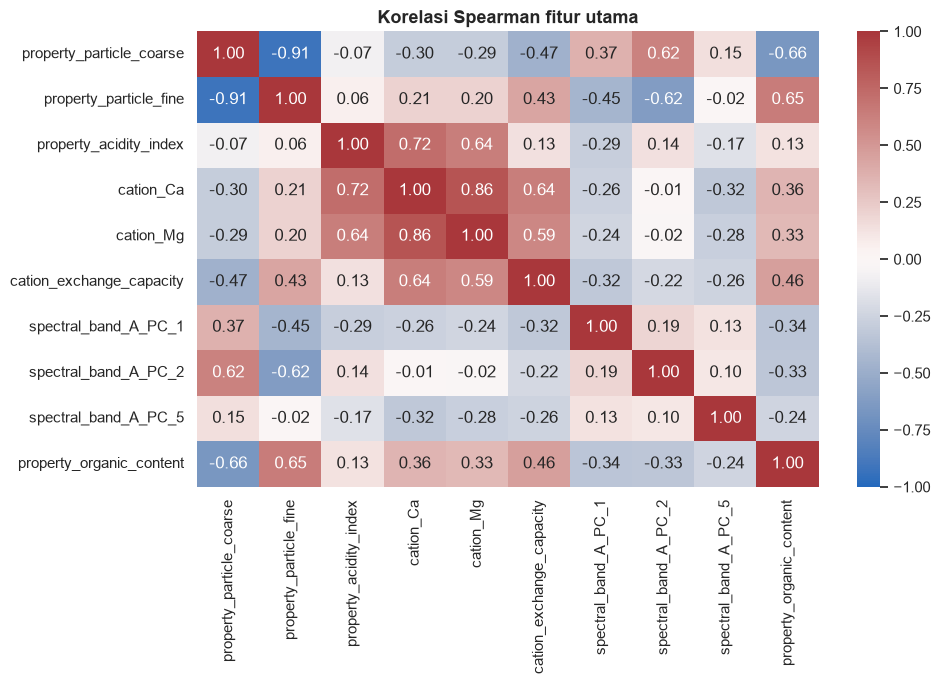

,feature,VIF
0,property_particle_coarse,6.0290
1,property_particle_fine,5.7258
3,cation_Ca,2.9186
4,cation_Mg,2.4334
5,cation_exchange_capacity,1.6396
2,property_acidity_index,1.0850


In [10]:
numeric_train = train.select_dtypes(include=np.number)
spearman_corr = numeric_train.corr(method="spearman")

upper_mask = np.triu(np.ones(spearman_corr.shape), k=1).astype(bool)
high_pairs = (
    spearman_corr.where(upper_mask)
    .stack()
    .rename("spearman_r")
    .to_frame()
)
high_pairs["abs_r"] = high_pairs["spearman_r"].abs()
high_pairs = high_pairs.sort_values("abs_r", ascending=False)
display(high_pairs.head(20))

corr_features = [
    "property_particle_coarse", "property_particle_fine",
    "property_acidity_index", "cation_Ca", "cation_Mg",
    "cation_exchange_capacity", "spectral_band_A_PC_1",
    "spectral_band_A_PC_2", "spectral_band_A_PC_5", TARGET,
]
plt.figure(figsize=(10, 7))
sns.heatmap(
    train[corr_features].corr(method="spearman"),
    annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1
)
plt.title("Korelasi Spearman fitur utama")
plt.tight_layout()
plt.show()

vif_cols = [
    "property_particle_coarse", "property_particle_fine",
    "property_acidity_index", "cation_Ca", "cation_Mg",
    "cation_exchange_capacity",
]
vif_matrix = SimpleImputer(strategy="median").fit_transform(train[vif_cols])
vif_matrix = StandardScaler().fit_transform(vif_matrix)
vif_rows = []
for i, feature in enumerate(vif_cols):
    other = np.arange(len(vif_cols)) != i
    r2 = LinearRegression().fit(vif_matrix[:, other], vif_matrix[:, i]).score(
        vif_matrix[:, other], vif_matrix[:, i]
    )
    vif_rows.append({"feature": feature, "VIF": 1 / (1 - r2)})
vif_table = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
display(vif_table)

**Jawaban Soal 6**

Pasangan paling kuat adalah `property_particle_coarse` dan `property_particle_fine`
(Spearman sekitar **-0,91**), diikuti `cation_Ca` dan `cation_Mg` (sekitar **0,86**).
VIF fraksi kasar dan halus berada di sekitar **6,03** dan **5,73**, sehingga ada multikolinearitas
moderat yang perlu diperhatikan untuk model linear. Komponen PCA dalam blok spektral umumnya tidak
memperlihatkan korelasi pairwise ekstrem, sesuai tujuan reduksi dimensi PCA.

Model utama adalah tree boosting sehingga tidak membutuhkan inversi matriks dan jauh lebih tahan
terhadap multikolinearitas daripada regresi linear. Fitur asli tetap dipertahankan, sementara
`fine_fraction` dan `particle_total` ditambahkan agar hubungan komposisional lebih mudah dipelajari.
Konsekuensinya, feature importance tidak boleh ditafsirkan sebagai efek kausal individual karena
kontribusi dapat terbagi di antara fitur yang berkorelasi.

## 4. Feature engineering

In [11]:
def make_features(df):
    X = df.drop(columns=[TARGET], errors="ignore").copy()
    X = X.drop(columns=["sample_id"], errors="ignore")

    band_a = [c for c in X.columns if c.startswith("spectral_band_A_PC_")]
    band_b = [c for c in X.columns if c.startswith("spectral_band_B_PC_")]
    chemistry = [
        "property_acidity_index", "cation_Ca", "cation_Mg",
        "cation_Na", "cation_exchange_capacity",
    ]

    # Missingness dapat mencerminkan alat/laboratorium/sumber data yang berbeda.
    X["missing_total"] = X.isna().sum(axis=1)
    X["chem_missing_count"] = X[chemistry].isna().sum(axis=1)
    X["band_B_available_actual"] = (
        X[band_b].notna().any(axis=1).map({True: "YES", False: "NO"})
    )
    X["band_B_missing_count"] = X[band_b].isna().sum(axis=1)
    X["coordinates_available"] = (
        X[["latitude", "longitude"]].notna().all(axis=1)
        .map({True: "YES", False: "NO"})
    )

    # Ringkasan energi/penyebaran komponen PCA spektral.
    for prefix, cols in [("A", band_a), ("B", band_b)]:
        values = X[cols]
        X[f"spectral_{prefix}_mean"] = values.mean(axis=1)
        X[f"spectral_{prefix}_std"] = values.std(axis=1)
        X[f"spectral_{prefix}_l2"] = np.sqrt((values ** 2).sum(axis=1))
        X[f"spectral_{prefix}_max_abs"] = values.abs().max(axis=1)
        X[f"spectral_{prefix}_abs_sum"] = values.abs().sum(axis=1)
        X[f"spectral_{prefix}_pos_count"] = (values > 0).sum(axis=1)

    eps = 1e-6
    X["particle_total"] = (
        X["property_particle_coarse"] + X["property_particle_fine"]
    )
    X["fine_fraction"] = (
        X["property_particle_fine"] / (X["particle_total"] + eps)
    )
    X["coarse_fine_ratio"] = (
        X["property_particle_coarse"] / (X["property_particle_fine"].abs() + eps)
    )
    X["base_cation_sum"] = X[["cation_Ca", "cation_Mg", "cation_Na"]].sum(
        axis=1, min_count=1
    )
    X["ca_mg_ratio"] = X["cation_Ca"] / (X["cation_Mg"].abs() + eps)
    X["base_to_cec_ratio"] = (
        X["base_cation_sum"] / (X["cation_exchange_capacity"].abs() + eps)
    )
    X["log_cec"] = np.log1p(X["cation_exchange_capacity"].clip(lower=0))

    # Interaksi kategori membantu model memahami konteks hierarkis.
    X["geo_hierarchy"] = (
        X["geo_zone_macro"].astype(str) + "|"
        + X["geo_zone_meso"].astype(str) + "|"
        + X["geo_zone_micro"].astype(str)
    )
    X["biome_landcover"] = (
        X["biome"].astype(str) + "|" + X["land_cover_type"].astype(str)
    )
    X["source_bandB"] = (
        X["source_id"].astype(str) + "|"
        + X["band_B_available_actual"].astype(str)
    )
    X["macro_biome"] = (
        X["geo_zone_macro"].astype(str) + "|" + X["biome"].astype(str)
    )
    X["macro_landcover"] = (
        X["geo_zone_macro"].astype(str) + "|" + X["land_cover_type"].astype(str)
    )

    # Grid kasar hanya digunakan jika koordinat tersedia.
    X["lat_round_1"] = X["latitude"].round(1)
    X["lon_round_1"] = X["longitude"].round(1)

    categorical_cols = X.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()
    for col in categorical_cols:
        X[col] = X[col].fillna("Missing").astype(str)

    return X, categorical_cols


def make_raw_features(df):
    X = df.drop(columns=[TARGET, "sample_id"], errors="ignore").copy()
    categorical_cols = X.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()
    for col in categorical_cols:
        X[col] = X[col].fillna("Missing").astype(str)
    return X, categorical_cols


X, categorical_cols = make_features(train)
X_test, categorical_cols_test = make_features(test)
y = train[TARGET].copy()

assert X.columns.equals(X_test.columns)
assert categorical_cols == categorical_cols_test

print(f"Shape setelah feature engineering: {X.shape}")
print(f"Jumlah fitur kategorikal CatBoost: {len(categorical_cols)}")

Shape setelah feature engineering: (11210, 81)
Jumlah fitur kategorikal CatBoost: 18


## Soal 7. Fitur baru dan manfaatnya

Fitur yang dibuat:

- **indikator missingness:** `missing_total`, `chem_missing_count`,
  `band_B_available_actual`, `band_B_missing_count`, dan `coordinates_available`;
- **ringkasan spektral:** mean, standar deviasi, norma L2, nilai absolut maksimum, jumlah absolut, dan jumlah komponen positif untuk setiap
  blok PCA A/B;
- **fitur tekstur:** `particle_total`, `fine_fraction`, dan `coarse_fine_ratio`;
- **fitur kimia:** jumlah kation basa, rasio Ca/Mg, rasio kation terhadap KTK, dan `log_cec`;
- **interaksi geografis/ekologis:** `geo_hierarchy`, `biome_landcover`, `source_bandB`, `macro_biome`, dan `macro_landcover`;
- **grid koordinat kasar:** lintang/bujur dibulatkan 0,1 derajat.

Missingness tidak dianggap sekadar gangguan karena pola ketidaktersediaan band B berkaitan dengan
alat atau sumber pengukuran. Ringkasan spektral memberi model ukuran energi dan penyebaran sinyal
selain tiap komponen PCA individual. Rasio tekstur dan kimia membantu merepresentasikan hubungan
komposisional yang sulit ditangkap hanya dari nilai mentah.

## 5. Ablation test sederhana: fitur mentah vs feature engineering

In [12]:
split_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")
idx_train, idx_valid = train_test_split(
    np.arange(len(train)),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=split_bins,
)

X_raw, raw_cat_cols = make_raw_features(train)
ablation_results = []

for label, features, cat_cols in [
    ("Raw features", X_raw, raw_cat_cols),
    ("Engineered features", X, categorical_cols),
]:
    model = CatBoostRegressor(
        iterations=600,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=8,
        random_strength=1,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )
    model.fit(
        features.iloc[idx_train],
        y.iloc[idx_train],
        cat_features=cat_cols,
        eval_set=(features.iloc[idx_valid], y.iloc[idx_valid]),
        early_stopping_rounds=100,
        verbose=False,
    )
    valid_pred = model.predict(features.iloc[idx_valid])
    ablation_results.append({
        "feature_set": label,
        "best_iteration": model.get_best_iteration(),
        "validation_RMSE": root_mean_squared_error(y.iloc[idx_valid], valid_pred),
        "validation_MAE": mean_absolute_error(y.iloc[idx_valid], valid_pred),
    })

ablation_table = pd.DataFrame(ablation_results).set_index("feature_set")
ablation_table["RMSE_improvement_vs_raw"] = (
    ablation_table.loc["Raw features", "validation_RMSE"]
    - ablation_table["validation_RMSE"]
)
display(ablation_table)

,best_iteration,validation_RMSE,validation_MAE,RMSE_improvement_vs_raw
feature_set,,,,
Raw features,598,12.0081,7.5585,0.0000
Engineered features,599,11.9375,7.5006,0.0706


## 6. Validasi silang, training model, dan prediksi test

In [13]:
y_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cat_oof = np.zeros(len(train))
cat_test_pred = np.zeros(len(test))
et_oof = np.zeros(len(train))
et_test_pred = np.zeros(len(test))
fold_rows = []
importance_rows = []
BLEND_CATBOOST_WEIGHT = 0.475
BLEND_EXTRATREES_WEIGHT = 1 - BLEND_CATBOOST_WEIGHT

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
extra_cat_cols = [col for col in X.columns if col not in numeric_cols]
extra_preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), extra_cat_cols),
])

for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y_bins), start=1):
    cat_model = CatBoostRegressor(
        iterations=CATBOOST_ITERATIONS,
        depth=6,
        learning_rate=0.045,
        l2_leaf_reg=8,
        random_strength=1.2,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=RANDOM_STATE + fold,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )
    cat_model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx],
        cat_features=categorical_cols,
        eval_set=(X.iloc[valid_idx], y.iloc[valid_idx]),
        early_stopping_rounds=130,
        verbose=False,
    )

    extra_model = Pipeline([
        ("preprocess", extra_preprocess),
        ("model", ExtraTreesRegressor(
            n_estimators=600,
            min_samples_leaf=2,
            max_features=0.8,
            random_state=RANDOM_STATE + fold,
            n_jobs=-1,
        )),
    ])
    extra_model.fit(X.iloc[train_idx], y.iloc[train_idx])

    cat_train_pred = cat_model.predict(X.iloc[train_idx])
    cat_valid_pred = cat_model.predict(X.iloc[valid_idx])
    extra_train_pred = extra_model.predict(X.iloc[train_idx])
    extra_valid_pred = extra_model.predict(X.iloc[valid_idx])

    blend_train_pred = (
        BLEND_CATBOOST_WEIGHT * cat_train_pred
        + BLEND_EXTRATREES_WEIGHT * extra_train_pred
    )
    blend_valid_pred = (
        BLEND_CATBOOST_WEIGHT * cat_valid_pred
        + BLEND_EXTRATREES_WEIGHT * extra_valid_pred
    )

    cat_oof[valid_idx] = cat_valid_pred
    et_oof[valid_idx] = extra_valid_pred
    cat_test_pred += cat_model.predict(X_test) / N_FOLDS
    et_test_pred += extra_model.predict(X_test) / N_FOLDS

    fold_rows.append({
        "fold": fold,
        "catboost_best_iteration": cat_model.get_best_iteration(),
        "catboost_validation_RMSE": root_mean_squared_error(y.iloc[valid_idx], cat_valid_pred),
        "extratrees_validation_RMSE": root_mean_squared_error(y.iloc[valid_idx], extra_valid_pred),
        "train_RMSE": root_mean_squared_error(y.iloc[train_idx], blend_train_pred),
        "validation_RMSE": root_mean_squared_error(y.iloc[valid_idx], blend_valid_pred),
        "validation_MAE": mean_absolute_error(y.iloc[valid_idx], blend_valid_pred),
        "validation_R2": r2_score(y.iloc[valid_idx], blend_valid_pred),
    })

    importance_rows.append(pd.DataFrame({
        "feature": X.columns,
        "importance": cat_model.get_feature_importance(),
        "fold": fold,
    }))
    print(f"Fold {fold} selesai.")

catboost_metrics = {
    "RMSE": root_mean_squared_error(y, cat_oof),
    "MAE": mean_absolute_error(y, cat_oof),
    "R2": r2_score(y, cat_oof),
}
extratrees_metrics = {
    "RMSE": root_mean_squared_error(y, et_oof),
    "MAE": mean_absolute_error(y, et_oof),
    "R2": r2_score(y, et_oof),
}

oof_pred = BLEND_CATBOOST_WEIGHT * cat_oof + BLEND_EXTRATREES_WEIGHT * et_oof
test_pred = BLEND_CATBOOST_WEIGHT * cat_test_pred + BLEND_EXTRATREES_WEIGHT * et_test_pred

ensemble_metrics = {
    "RMSE": root_mean_squared_error(y, oof_pred),
    "MAE": mean_absolute_error(y, oof_pred),
    "R2": r2_score(y, oof_pred),
}

fold_metrics = pd.DataFrame(fold_rows).set_index("fold")
model_comparison = pd.DataFrame([
    {"model": "CatBoost 5-fold", **catboost_metrics},
    {"model": "ExtraTrees 5-fold", **extratrees_metrics},
    {"model": f"Blend {BLEND_CATBOOST_WEIGHT:.3f} CatBoost + {BLEND_EXTRATREES_WEIGHT:.3f} ExtraTrees", **ensemble_metrics},
]).set_index("model")

display(fold_metrics)
display(model_comparison.sort_values("RMSE"))

Fold 1 selesai.


Fold 2 selesai.


Fold 3 selesai.


Fold 4 selesai.


Fold 5 selesai.


,catboost_best_iteration,catboost_validation_RMSE,extratrees_validation_RMSE,train_RMSE,validation_RMSE,validation_MAE,validation_R2
fold,,,,,,,
1,998,11.9568,11.9719,5.0683,11.6695,7.2857,0.7507
2,999,11.7377,11.7836,5.2143,11.3708,7.0863,0.7580
3,999,11.9538,11.5812,5.0769,11.4390,7.2695,0.7629
4,984,11.8754,11.9969,5.1686,11.6114,7.1105,0.7597
5,994,10.9466,10.9349,5.2609,10.5977,6.8201,0.7740


,RMSE,MAE,R2
model,,,
Blend 0.475 CatBoost + 0.525 ExtraTrees,11.3442,7.1144,0.7609
ExtraTrees 5-fold,11.6602,7.2919,0.7473
CatBoost 5-fold,11.7003,7.3734,0.7456


,nilai
OOF_RMSE,11.3442
OOF_MAE,7.1144
OOF_MedianAE,4.5046
OOF_RMSLE,0.3030
OOF_R2,0.7609
Mean_train_RMSE,5.1578
Mean_validation_RMSE,11.3377
Generalization_gap,6.1799


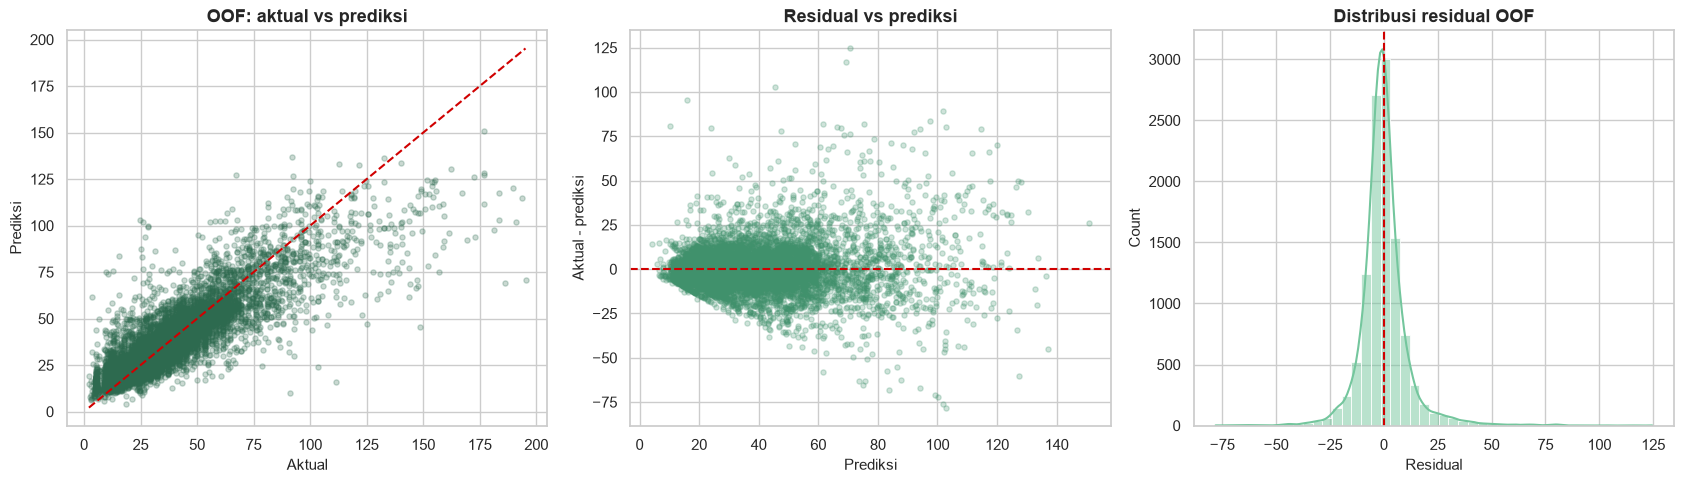

In [14]:
overall_metrics = pd.Series({
    "OOF_RMSE": root_mean_squared_error(y, oof_pred),
    "OOF_MAE": mean_absolute_error(y, oof_pred),
    "OOF_MedianAE": median_absolute_error(y, oof_pred),
    "OOF_RMSLE": np.sqrt(mean_squared_log_error(y, np.clip(oof_pred, 0, None))),
    "OOF_R2": r2_score(y, oof_pred),
    "Mean_train_RMSE": fold_metrics["train_RMSE"].mean(),
    "Mean_validation_RMSE": fold_metrics["validation_RMSE"].mean(),
})
overall_metrics["Generalization_gap"] = (
    overall_metrics["Mean_validation_RMSE"]
    - overall_metrics["Mean_train_RMSE"]
)
display(overall_metrics.to_frame("nilai"))

residuals = y - oof_pred
_, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(y, oof_pred, alpha=0.25, s=14, color=PALETTE[1])
lims = [min(y.min(), oof_pred.min()), max(y.max(), oof_pred.max())]
axes[0].plot(lims, lims, "--", color="#D00000")
axes[0].set_title("OOF: aktual vs prediksi")
axes[0].set_xlabel("Aktual")
axes[0].set_ylabel("Prediksi")

axes[1].scatter(oof_pred, residuals, alpha=0.25, s=14, color=PALETTE[2])
axes[1].axhline(0, ls="--", color="#D00000")
axes[1].set_title("Residual vs prediksi")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Aktual - prediksi")

sns.histplot(residuals, bins=45, kde=True, color=PALETTE[3], ax=axes[2])
axes[2].axvline(0, ls="--", color="#D00000")
axes[2].set_title("Distribusi residual OOF")
axes[2].set_xlabel("Residual")
plt.tight_layout()
plt.show()

In [15]:
mean_train_rmse = fold_metrics["train_RMSE"].mean()
mean_valid_rmse = fold_metrics["validation_RMSE"].mean()
gap = mean_valid_rmse - mean_train_rmse
relative_gap = gap / mean_valid_rmse * 100

if relative_gap > 40:
    fit_diagnosis = "overfit cukup jelas pada training fit, tetapi generalisasi OOF membaik melalui ensemble"
elif relative_gap > 20:
    fit_diagnosis = "overfit ringan hingga moderat"
elif overall_metrics["OOF_R2"] < 0.25:
    fit_diagnosis = "cenderung underfit"
else:
    fit_diagnosis = "cukup seimbang"

display(Markdown(f'''
## Soal 2. Apakah model overfit atau underfit?

Berdasarkan {N_FOLDS}-fold out-of-fold validation, model **{fit_diagnosis}**.
Mean train RMSE adalah **{mean_train_rmse:.3f}**, mean validation RMSE
**{mean_valid_rmse:.3f}**, sehingga generalization gap **{gap:.3f}**
({relative_gap:.1f}% dari validation RMSE). OOF RMSE keseluruhan adalah
**{overall_metrics["OOF_RMSE"]:.3f}** dengan R² **{overall_metrics["OOF_R2"]:.3f}**.

Gap train-validation menunjukkan model mempelajari sebagian pola spesifik fold, tetapi performa
validasi jauh lebih baik daripada baseline median dan R² masih kuat; karena itu model tidak underfit.
Mitigasi yang digunakan adalah validasi silang {N_FOLDS}-fold, regularisasi CatBoost, early stopping,
serta blending CatBoost dan ExtraTrees untuk menurunkan varians prediksi. Untuk deployment geografis baru,
mitigasi berikutnya adalah GroupKFold/spatial blocking berdasarkan `source_id` atau zona.
'''))


## Soal 2. Apakah model overfit atau underfit?

Berdasarkan 5-fold out-of-fold validation, model **overfit cukup jelas pada training fit, tetapi generalisasi OOF membaik melalui ensemble**.
Mean train RMSE adalah **5.158**, mean validation RMSE
**11.338**, sehingga generalization gap **6.180**
(54.5% dari validation RMSE). OOF RMSE keseluruhan adalah
**11.344** dengan R² **0.761**.

Gap train-validation menunjukkan model mempelajari sebagian pola spesifik fold, tetapi performa
validasi jauh lebih baik daripada baseline median dan R² masih kuat; karena itu model tidak underfit.
Mitigasi yang digunakan adalah validasi silang 5-fold, regularisasi CatBoost, early stopping,
serta blending CatBoost dan ExtraTrees untuk menurunkan varians prediksi. Untuk deployment geografis baru,
mitigasi berikutnya adalah GroupKFold/spatial blocking berdasarkan `source_id` atau zona.


,feature,importance
38,source_id,20.2025
12,coarse_fine_ratio,6.9476
61,spectral_band_A_PC_5,5.6818
14,fine_fraction,4.5733
59,spectral_band_A_PC_3,3.6076
10,cation_exchange_capacity,3.5974
33,property_particle_coarse,3.5421
24,log_cec,3.4604
36,sampling_strategy,2.6395
57,spectral_band_A_PC_15,2.6045


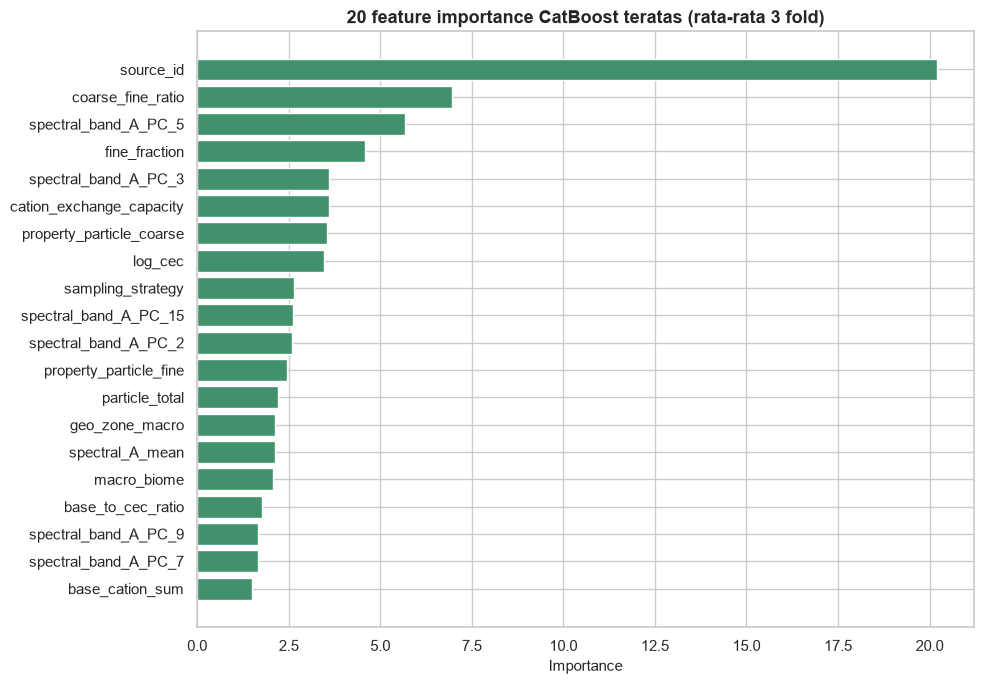

In [16]:
feature_importance = (
    pd.concat(importance_rows, ignore_index=True)
    .groupby("feature", as_index=False)["importance"].mean()
    .sort_values("importance", ascending=False)
)
display(feature_importance.head(20))

plt.figure(figsize=(10, 7))
top_imp = feature_importance.head(20).sort_values("importance")
plt.barh(top_imp["feature"], top_imp["importance"], color=PALETTE[2])
plt.title("20 feature importance CatBoost teratas (rata-rata 3 fold)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Soal 8. Model yang digunakan dan alasan pemilihan

Model final menggunakan **ensemble rata-rata berbobot**: 47,5% CatBoostRegressor dan 52,5% ExtraTreesRegressor, keduanya dilatih dengan 5-fold cross-validation.

Alasan pemilihan:

- CatBoost menangani fitur kategorikal langsung tanpa one-hot encoding berdimensi besar;
- CatBoost menangani `NaN` numerik secara native, penting karena band B hilang pada mayoritas sampel;
- ExtraTrees memberi model nonlinear berbasis bagging yang varians dan biasnya berbeda dari boosting;
- blend CatBoost + ExtraTrees menurunkan OOF RMSE dibanding masing-masing model tunggal;
- kombinasi keduanya cocok untuk representasi spektral PCA karena mampu menangkap interaksi nonlinear antara spektrum, tekstur, kimia tanah, sumber data, dan geografi.

Dibanding regresi linear/PLS, ensemble ini lebih fleksibel terhadap interaksi dan missingness. Kekurangannya adalah interpretasi kausal lebih lemah, sehingga feature importance tetap harus dibaca sebagai indikasi prediktif, bukan efek sebab-akibat.

## Soal 9. Kesesuaian RMSE

In [17]:
display(Markdown(f'''
Target memiliki skewness **{y.skew():.2f}** dan ekor kanan panjang. RMSE kompetisi sebesar
**{overall_metrics["OOF_RMSE"]:.3f}**, sedangkan MAE **{overall_metrics["OOF_MAE"]:.3f}** dan
median absolute error **{overall_metrics["OOF_MedianAE"]:.3f}**.

**RMSE tepat apabila kesalahan besar pada sampel berkandungan organik tinggi dianggap sangat mahal**,
karena error dikuadratkan. Ini konsisten dengan kebutuhan kompetisi untuk menghukum prediksi yang
meleset jauh. Namun, RMSE sendirian kurang robust pada distribusi right-skewed dan dapat membuat
optimasi terlalu berfokus pada sedikit nilai ekstrem.

Rekomendasi praktis adalah mempertahankan RMSE sebagai metrik utama, tetapi selalu mendampinginya
dengan **MAE** (mudah ditafsirkan dan lebih robust), **MedianAE**, serta **RMSLE**
({overall_metrics["OOF_RMSLE"]:.3f}) bila kesalahan relatif lebih relevan daripada kesalahan absolut.
Error juga perlu dipecah per zona, bioma, dan rentang target agar rata-rata global tidak menyembunyikan
kelompok yang berkinerja buruk.
'''))


Target memiliki skewness **2.03** dan ekor kanan panjang. RMSE kompetisi sebesar
**11.344**, sedangkan MAE **7.114** dan
median absolute error **4.505**.

**RMSE tepat apabila kesalahan besar pada sampel berkandungan organik tinggi dianggap sangat mahal**,
karena error dikuadratkan. Ini konsisten dengan kebutuhan kompetisi untuk menghukum prediksi yang
meleset jauh. Namun, RMSE sendirian kurang robust pada distribusi right-skewed dan dapat membuat
optimasi terlalu berfokus pada sedikit nilai ekstrem.

Rekomendasi praktis adalah mempertahankan RMSE sebagai metrik utama, tetapi selalu mendampinginya
dengan **MAE** (mudah ditafsirkan dan lebih robust), **MedianAE**, serta **RMSLE**
(0.303) bila kesalahan relatif lebih relevan daripada kesalahan absolut.
Error juga perlu dipecah per zona, bioma, dan rentang target agar rata-rata global tidak menyembunyikan
kelompok yang berkinerja buruk.


## Soal 10. Data eksternal yang paling bernilai

Data eksternal yang diprioritaskan:

1. **Iklim:** curah hujan, temperatur, evapotranspirasi, dan seasonality. Variabel ini mengontrol
   produksi biomassa dan laju dekomposisi bahan organik.
2. **Topografi/DEM:** elevasi, slope, aspect, curvature, dan topographic wetness index untuk menangkap
   erosi, drainase, serta akumulasi material.
3. **Riwayat pengindraan jauh:** NDVI/EVI, bare-soil index, kelembapan, kebakaran, dan perubahan tutupan
   lahan multi-tahun. Riwayat lebih informatif daripada snapshot tunggal.
4. **Pengelolaan lahan:** rotasi tanaman, pengolahan tanah, residu, irigasi, pupuk organik/mineral,
   intensitas penggembalaan, dan umur penggunaan lahan.
5. **Peta tanah/geologi resolusi tinggi:** kelas tanah, mineralogi liat, drainase, dan bahan induk.

Integrasi dilakukan melalui spatial join berdasarkan latitude-longitude, penyelarasan tanggal sampling,
agregasi temporal (misalnya mean dan tren 1-3 tahun sebelum sampling), serta indikator kualitas sumber.
Pipeline harus mencegah leakage dengan hanya memakai data yang tersedia sebelum waktu sampling.
Evaluasi akhir sebaiknya menggunakan spatial blocking agar keuntungan data eksternal benar-benar
mencerminkan generalisasi ke lokasi baru.

## Preview prediksi test dengan semua kolom

Sebelum membuat file submission final, tabel berikut menampilkan seluruh kolom pada data test ditambah kolom prediksi target `property_organic_content`. Preview kedua menampilkan format final submission yang hanya berisi `sample_id` dan `property_organic_content`.

In [18]:
test_prediction_preview = test.copy()
test_prediction_preview[TARGET] = np.clip(test_pred, 0, None)

# Tampilkan semua kolom agar prediksi target bisa diperiksa bersama fitur test.
with pd.option_context("display.max_columns", None, "display.width", 240):
    display(test_prediction_preview.head(10))

submission_preview = test_prediction_preview[["sample_id", TARGET]].copy()
display(submission_preview.head(10))

,sample_id,source_id,has_band_A_spectrum,has_band_B_spectrum,sampling_strategy,sampling_depth_cm,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,biome,parent_rock_type,property_particle_coarse,property_particle_fine,property_acidity_index,cation_Ca,cation_Mg,cation_Na,cation_exchange_capacity,latitude,longitude,spectral_band_A_PC_1,spectral_band_A_PC_2,spectral_band_A_PC_3,spectral_band_A_PC_4,spectral_band_A_PC_5,spectral_band_A_PC_6,spectral_band_A_PC_7,spectral_band_A_PC_8,spectral_band_A_PC_9,spectral_band_A_PC_10,spectral_band_A_PC_11,spectral_band_A_PC_12,spectral_band_A_PC_13,spectral_band_A_PC_14,spectral_band_A_PC_15,spectral_band_B_PC_1,spectral_band_B_PC_2,spectral_band_B_PC_3,spectral_band_B_PC_4,spectral_band_B_PC_5,spectral_band_B_PC_6,spectral_band_B_PC_7,spectral_band_B_PC_8,spectral_band_B_PC_9,spectral_band_B_PC_10,spectral_band_B_PC_11,spectral_band_B_PC_12,spectral_band_B_PC_13,spectral_band_B_PC_14,spectral_band_B_PC_15,property_organic_content
0,test_00001,Source_02,YES,NO,Profile,0-20,MW,Unknown,State_02,Seasonal Semideciduous Forest,Mata Atlantica,Igneous Rock,"1,602.2109","1,413.7155",13.1947,6.2832,3.1416,NaN,131.6326,NaN,NaN,-6.4091,-0.1442,0.3317,-0.0154,0.1147,-0.0581,-0.0047,-0.0020,0.0247,0.0193,0.0119,-0.0056,-0.0328,0.0128,0.0025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.5408
1,test_00002,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.0071,-0.2240,0.3963,-0.1900,0.1864,-0.0758,0.0413,-0.0173,0.0328,0.0479,-0.0039,-0.0142,-0.0176,0.0146,-0.0328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.4735
2,test_00003,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.9447,-0.9474,0.8469,0.2073,-0.2103,-0.1016,0.0585,-0.0714,0.0691,-0.0637,-0.0985,-0.0315,-0.0489,0.0050,-0.0044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.7617
3,test_00004,Source_02,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,Mata Atlantica,Igneous Rock,"2,576.1038",502.6544,13.1947,37.6991,21.9911,NaN,120.0087,NaN,NaN,-2.5058,0.8690,-0.4774,0.1560,-0.0332,0.0248,0.0861,0.0728,-0.0323,-0.0329,-0.0331,-0.0238,-0.0051,-0.0156,-0.0060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.5303
4,test_00005,Source_02,YES,NO,Auger,0-20,MW,Unknown,State_02,Areas of Ecological Tension,Cerrado,Sedimentary Rock,"2,230.5289",656.5923,NaN,18.8495,9.4248,NaN,176.2432,NaN,NaN,-1.0554,0.7840,-0.1235,0.0208,0.1642,-0.0236,0.0991,0.0896,0.0224,-0.0049,-0.0588,0.0159,0.0294,0.0388,0.0528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.2587
5,test_00006,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,Mata Atlantica,Sedimentary Rock,"2,409.5995",515.2208,NaN,36.1283,11.6239,NaN,114.6680,-29.6251,-53.7853,4.0387,0.0358,0.4745,-0.0313,-0.1748,0.1678,0.0670,0.1343,0.1907,0.1515,-0.0963,-0.0141,0.1011,-0.0727,0.0200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.1830
6,test_00007,Source_28,YES,NO,Profile,0-20,MW,Loc_022,State_04,Savannah,Cerrado,Sedimentary Rock,369.8757,"2,055.3954",NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.5938,-1.7172,-0.5271,-0.2996,0.0728,-0.0474,-0.3377,-0.2073,-0.0575,0.0344,-0.0536,-0.0710,-0.0014,-0.0349,-0.0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.9713
7,test_00008,Source_05,YES,YES,Profile,0-20,SE,Unknown,State_05,Savannah,Cerrado,Igneous Rock,62.8318,"2,042.0335",NaN,47.1238,3.1416,NaN,111.8406,NaN,NaN,7.5419,-2.0430,1.3904,0.4482,-0.0288,-0.0210,-0.2690,-0.0126,-0.2036,-0.2124,-0.0943,0.0583,0.0161,-0.0630,-0.0567,0.5655,0.2729,-0.0969,0.0157,-0.0330,-0.0105,0.0074,-0.0032,0.0063,0.0016,0.0108,0.0140,0.0140,0.0079,0.0038,22.7677
8,test_00009,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,Mata Atlantica,Sedimentary Rock,"2,623.2276",376.9908,NaN,37.3849,15.7080,NaN,104.9291,NaN,NaN,-1.4916,0.7082,0.0017,-0.1265,

,sample_id,property_organic_content
0,test_00001,24.5408
1,test_00002,16.4735
2,test_00003,30.7617
3,test_00004,22.5303
4,test_00005,29.2587
5,test_00006,20.1830
6,test_00007,38.9713
7,test_00008,22.7677
8,test_00009,20.6563
9,test_00010,39.1224


## 7. Membuat file submission

In [19]:
submission = sample_submission.copy()
submission[TARGET] = np.clip(test_pred, 0, None)

assert submission.shape == sample_submission.shape
assert submission.columns.tolist() == ["sample_id", TARGET]
assert submission["sample_id"].equals(test["sample_id"])
assert submission[TARGET].notna().all()
assert np.isfinite(submission[TARGET]).all()

submission_path = ROOT / "submission.csv"
submission.to_csv(submission_path, index=False)

print(f"Submission tersimpan: {submission_path}")
print(f"Shape: {submission.shape}")
display(submission.head(10))
display(submission[TARGET].describe().to_frame("prediksi_test"))

Submission tersimpan: C:\Users\nicho\Documents\Projects\compfest\submission.csv
Shape: (2670, 2)


,sample_id,property_organic_content
0,test_00001,24.5408
1,test_00002,16.4735
2,test_00003,30.7617
3,test_00004,22.5303
4,test_00005,29.2587
5,test_00006,20.1830
6,test_00007,38.9713
7,test_00008,22.7677
8,test_00009,20.6563
9,test_00010,39.1224


,prediksi_test
count,"2,670.0000"
mean,34.5903
std,19.4002
min,8.0354
25%,20.8957
50%,28.3877
75%,43.5649
max,142.1501


## Kesimpulan

Notebook telah:

- memvalidasi struktur train, test, dan sample submission;
- menganalisis missingness, distribusi target, geografi, ekosistem, outlier, dan multikolinearitas;
- membuat feature engineering khusus data tanah dan spektral;
- melatih ensemble CatBoost + ExtraTrees dengan out-of-fold validation;
- mengevaluasi overfit, residual, feature importance, dan metrik pendamping;
- menghasilkan `submission.csv` dengan dua kolom yang sama persis seperti contoh.